# 00b — GBIF IUCN Red List Status

Fetch IUCN Red List categories for all species in our dataset via the GBIF
Species API. This enriches the species list from notebook 00 with conservation
threat status, used downstream in the gap analysis (notebooks 30–31) to
prioritise which species to include.

In [1]:
import config
import pandas as pd
import numpy as np
import requests
import time
from concurrent.futures import ThreadPoolExecutor, as_completed

# Load GBIF data to get unique species + specieskeys
gbif = pd.read_parquet(config.GBIF_PARQUET, storage_options={'anon': False})
species_keys = gbif.groupby('species')['specieskey'].first().reset_index()
species_keys = species_keys.dropna(subset=['specieskey'])
species_keys['specieskey'] = species_keys['specieskey'].astype(int)
print(f'Unique species with specieskey: {len(species_keys):,}')

Unique species with specieskey: 10,497


In [2]:
def fetch_iucn_status(specieskey):
    """Fetch IUCN Red List category from GBIF Species API."""
    url = f'https://api.gbif.org/v1/species/{specieskey}/iucnRedListCategory'
    try:
        r = requests.get(url, timeout=10)
        if r.status_code == 200:
            data = r.json()
            return data.get('category', 'NOT_EVALUATED')
        elif r.status_code == 204:
            # No IUCN assessment available for this species
            return 'NOT_EVALUATED'
        return 'API_ERROR'
    except Exception:
        return 'API_ERROR'


# Fetch in parallel (GBIF API is generous with rate limits)
print(f'Fetching IUCN status for {len(species_keys):,} species...')
t0 = time.time()

results = {}
with ThreadPoolExecutor(max_workers=20) as executor:
    futures = {
        executor.submit(fetch_iucn_status, row.specieskey): row.species
        for row in species_keys.itertuples()
    }
    for i, future in enumerate(as_completed(futures)):
        sp = futures[future]
        results[sp] = future.result()
        if (i + 1) % 500 == 0:
            print(f'  {i+1}/{len(species_keys)} done...')

elapsed = time.time() - t0
print(f'Done in {elapsed:.0f}s')

Fetching IUCN status for 10,497 species...
  500/10497 done...
  1000/10497 done...
  1500/10497 done...
  2000/10497 done...
  2500/10497 done...
  3000/10497 done...
  3500/10497 done...
  4000/10497 done...
  4500/10497 done...
  5000/10497 done...
  5500/10497 done...
  6000/10497 done...
  6500/10497 done...
  7000/10497 done...
  7500/10497 done...
  8000/10497 done...
  8500/10497 done...
  9000/10497 done...
  9500/10497 done...
  10000/10497 done...
Done in 62s


In [3]:
# Build dataframe
status_df = pd.DataFrame([
    {'species': sp, 'iucn_category': cat}
    for sp, cat in results.items()
])

# Merge with record counts
record_counts = gbif['species'].value_counts().reset_index()
record_counts.columns = ['species', 'n_records']
status_df = status_df.merge(record_counts, on='species', how='left')

# Also check which species have suitability scores
scores_npz = np.load('gnn_training_output/suitability_scores.npz')
has_scores = set(k.replace('_', ' ') for k in scores_npz.files)
status_df['has_gnn_scores'] = status_df['species'].isin(has_scores)

print(f'Total species: {len(status_df):,}')
print(f'With GNN scores: {status_df["has_gnn_scores"].sum():,}')
print()
print(status_df['iucn_category'].value_counts().to_string())

Total species: 10,497
With GNN scores: 3,751

iucn_category
NOT_EVALUATED            9051
LEAST_CONCERN            1227
DATA_DEFICIENT             72
NEAR_THREATENED            48
VULNERABLE                 46
ENDANGERED                 38
CRITICALLY_ENDANGERED      13
EXTINCT_IN_THE_WILD         1
EXTINCT                     1


In [4]:
# IUCN category ordering (most to least threatened)
IUCN_ORDER = [
    'EXTINCT',              # EX
    'EXTINCT_IN_THE_WILD',  # EW
    'CRITICALLY_ENDANGERED',# CR
    'ENDANGERED',           # EN
    'VULNERABLE',           # VU
    'NEAR_THREATENED',      # NT
    'LEAST_CONCERN',        # LC
    'DATA_DEFICIENT',       # DD
    'NOT_EVALUATED',        # NE / missing
    'API_ERROR',
]

# Normalise: treat None as NOT_EVALUATED
status_df['iucn_category'] = status_df['iucn_category'].replace({
    None: 'NOT_EVALUATED',
})

# Summary table
summary = (
    status_df[status_df['has_gnn_scores']]
    .groupby('iucn_category')
    .agg(
        n_species=('species', 'count'),
        mean_records=('n_records', 'mean'),
    )
    .reindex([c for c in IUCN_ORDER if c in status_df['iucn_category'].values])
)
summary['pct'] = (summary['n_species'] / summary['n_species'].sum() * 100).round(1)

print('=== Species with GNN scores by IUCN category ===')
print(summary.to_string())
print(f'\nTotal: {summary["n_species"].sum():,}')

=== Species with GNN scores by IUCN category ===
                       n_species  mean_records   pct
iucn_category                                       
EXTINCT                      1.0   2617.000000   0.0
EXTINCT_IN_THE_WILD          NaN           NaN   NaN
CRITICALLY_ENDANGERED        NaN           NaN   NaN
ENDANGERED                   6.0    568.333333   0.2
VULNERABLE                   5.0   1580.800000   0.1
NEAR_THREATENED             12.0  10000.500000   0.3
LEAST_CONCERN              555.0   9604.879279  14.8
DATA_DEFICIENT              26.0   2325.576923   0.7
NOT_EVALUATED             3146.0   5381.051812  83.9

Total: 3,751.0


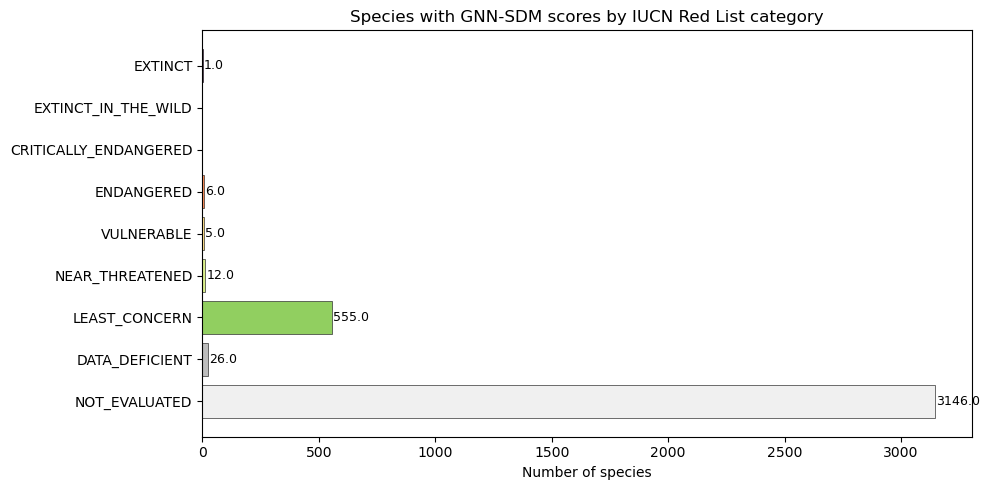

In [5]:
import matplotlib.pyplot as plt

# Visualise
colors = {
    'EXTINCT': '#4d004b',
    'EXTINCT_IN_THE_WILD': '#810f7c',
    'CRITICALLY_ENDANGERED': '#d73027',
    'ENDANGERED': '#fc8d59',
    'VULNERABLE': '#fee08b',
    'NEAR_THREATENED': '#d9ef8b',
    'LEAST_CONCERN': '#91cf60',
    'DATA_DEFICIENT': '#bdbdbd',
    'NOT_EVALUATED': '#f0f0f0',
}

fig, ax = plt.subplots(figsize=(10, 5))
cats = summary.index.tolist()
counts = summary['n_species'].values
bar_colors = [colors.get(c, '#cccccc') for c in cats]

ax.barh(cats, counts, color=bar_colors, edgecolor='#333333', linewidth=0.5)
ax.set_xlabel('Number of species')
ax.set_title('Species with GNN-SDM scores by IUCN Red List category')
ax.invert_yaxis()

for i, (cat, count) in enumerate(zip(cats, counts)):
    ax.text(count + 5, i, str(count), va='center', fontsize=9)

plt.tight_layout()
plt.show()

In [6]:
# Save for use in gap analysis job
output_path = 'species_threat_status.csv'
status_df.to_csv(output_path, index=False)
print(f'Saved to {output_path}')

# Show threatened species subset (CR + EN + VU + NT) that have GNN scores
threatened = status_df[
    (status_df['iucn_category'].isin(['CRITICALLY_ENDANGERED', 'ENDANGERED', 'VULNERABLE', 'NEAR_THREATENED']))
    & (status_df['has_gnn_scores'])
].sort_values('iucn_category')

print(f'\nThreatened species with GNN scores (CR+EN+VU+NT): {len(threatened)}')
print(f'These would be the priority subset for the gap analysis batch job.')
print()
print(threatened[['species', 'iucn_category', 'n_records']].head(30).to_string(index=False))

Saved to species_threat_status.csv

Threatened species with GNN scores (CR+EN+VU+NT): 23
These would be the priority subset for the gap analysis batch job.

                 species   iucn_category  n_records
           Ginkgo biloba      ENDANGERED        106
   Aldrovanda vesiculosa      ENDANGERED        156
Sequoiadendron giganteum      ENDANGERED        786
    Sequoia sempervirens      ENDANGERED        160
        Cedrus atlantica      ENDANGERED        232
                Poa laxa      ENDANGERED       1970
     Pulsatilla vulgaris NEAR_THREATENED       5115
    Poterium dodecandrum NEAR_THREATENED        119
  Platycladus orientalis NEAR_THREATENED        204
       Jacobaea uniflora NEAR_THREATENED       1689
      Trifolium saxatile NEAR_THREATENED       1299
       Woodsia pulchella NEAR_THREATENED        113
       Galanthus nivalis NEAR_THREATENED       6248
      Fraxinus excelsior NEAR_THREATENED      97508
        Eryngium alpinum NEAR_THREATENED       4864
Chamaecypar